$\renewcommand{\fl}{\operatorname{fl}}$

<div style='background-color:#002147; padding:20px; border-radius:8px'>
<h1 style='color:white;'>GMM132 – Cálculo Numérico</h1>
<h3 style='color:white;'>Aula 1: Estratégia Numérica, Erros e Ponto Flutuante</h3>
</div>

## 1️⃣ Estratégia de Solução Numérica

Processo físico → Modelo matemático → Discretização → Solução numérica.

![image.png](figures/num_model.png)

<div style="background-color: #fff3b0; padding: 12px; border-radius: 6px;">
⚠️ <b> A essência dos métodos numéricos está na discretização do contínuo.</b> ⚠️
</div>

Podemos representar o erro total como:

$$
E_{total} = E_{modelagem} + E_{truncamento} + E_{arredondamento}
$$

### 🔎 [__Exercício 1.1__](#exercício-1.1) 
1. Explique a diferença entre erro inerente e erro de truncamento.
2. Cite um exemplo de problema que não admite solução analítica.

## Introdução

O computador é uma máquina finita, capaz de armazenar e manipular apenas um **número finito de dados**. Por isso, números que não possuem representação finita, como os **irracionais** (por exemplo, $\pi$), não podem ser armazenados exatamente. Assim, cálculos como $\sin(\pi)$ não são feitos com o valor exato de $\pi$, mas sim com **aproximações numéricas** desse número.

Na prática, essas aproximações são suficientemente precisas para a maioria das aplicações. Nesta parte do curso, estudaremos **como os computadores representam números**, qual é a **qualidade dessas aproximações** e quais **problemas podem surgir devido aos erros numéricos**, especialmente quando muitas operações são realizadas em sequência. Um ponto importante é entender **como esses erros se comportam: se se acumulam ou se podem se cancelar**.

A seguir, veremos o que é $\pi$ para o computador.

In [34]:
import math
import numpy as np

np.float64(math.pi)

3.141592653589793

Como você pode ver, o computador armazena **uma aproximação** do número $\pi$. No exemplo acima aparecem os **16 primeiros dígitos significativos**, que estão corretos. Isso ocorre devido à forma como os números são representados em **dupla precisão (float64)**.

### 💡 Observação

O valor `math.pi` já é uma **aproximação em dupla precisão**, contendo cerca de **16 dígitos significativos corretos**, que é o limite da representação `float64`.

Para trabalhar com **mais dígitos de $\pi$**, é necessário utilizar **tipos numéricos de precisão arbitrária**. Em Python, isso pode ser feito com o módulo `decimal`, que permite definir explicitamente o número de dígitos usados nos cálculos.

In [2]:
from decimal import Decimal, getcontext

getcontext().prec = 50

pi = Decimal("3.14159265358979323846264338327950288419716939937510")
print(pi)

3.14159265358979323846264338327950288419716939937510


## 2️⃣ Medidas de Erro
<div style="background-color: #fff3b0; padding: 12px; border-radius: 6px;">

⚠️ Cálculo Numérico é a arte de aproximar quantidades, normalmente a solução de algum problema. Nada mais importante que saber quantificar se a aproximação é boa ou não. Nesta aula vamos ver como medir erros e qual o impacto de fazer contas em um computador.
<br></div>


Acima falamos que o computador armazena aproximações dos números (pelo menos no caso destes não admitirem representação finita). Ao se fazer uma aproximação, cometemos um pequeno *erro*. Vamos definir formalmente esse conceito.

### 📌Definições de erro
Seja $\hat{x}$ um valor que desejamos representar (ou calcular) e $x$ uma aproximação de $\hat{x}$. 

### 🔹 Erro Absoluto
O erro absoluto de $x$ com respeito a $\hat{x}$ é
$$
E_{abs}(\hat{x}) = |x - \hat{x}|.
$$
### 🔹 Erro Relativo
Já o *erro relativo* é
$$
E_{rel}(\hat{x}) = \frac{|x - \hat{x}|}{|\hat{x}|}.
$$

Observe que, para definir o erro relativo, precisamos que $\hat{x} \neq 0$.

### 🔹 Erro adimensional

Um outro tipo de erro que pode ser útil é o erro adimensional definido por
$$
E_{adm}(\hat{x}) = \frac{|x - \hat{x}|}{L},
$$
em que $L$ é uma constante que representa de alguma forma valores típicos esperados.

Vejamos agora dois exemplos. Considere que obtivemos $x = 0{,}9273$ para aproximar $\hat{x} = 1$. Quais os erros associados? Temos
$$
E_{abs} = |0{,}9273 - 1{,}0| = 0{,}0727,\quad\quad E_{rel} = \frac{|0{,}9273 - 1{,}0|}{|1{,}0|} = 0{,}0727.
$$
Nesse caso, como o valor desejado tem módulo 1, os erros absoluto e relativo coincidem.

Já para $x = 0{,}9273$ para aproximar $0{,}9$, teríamos
$$
E_{abs} = |0{,}9273 - 0{,}9| = 0{,}0273,\quad\quad E_{rel} = \frac{0{,}0273}{0{,}9} = 0{,}0303333333\ldots.
$$
Aqui o erro relativo é maior que o absoluto, dando mais peso ao erro porque o número que desejávamos aproximar tem módulo menor do que 1.

## 3️⃣ Representação de números no computador

<div class="alert alert-info">

Seria ideal que todas as contas feitas no computador fossem **exatas**, mas isso nem sempre é possível. Para entender por quê, precisamos compreender **como os números são representados internamente** e qual é a qualidade dessa representação.

</div>

Para armazenar números, os computadores utilizam o sistema de **ponto flutuante**, que guarda:

- uma quantidade fixa de **dígitos significativos**, e  
- um **expoente** que determina a posição da vírgula.

Assim, um número é representado por uma **mantissa** e um **expoente**.

### Componentes do sistema de ponto flutuante

Um sistema de ponto flutuante é caracterizado por:

1. **Base $b$**  
   Nos computadores geralmente $b=2$ (binário).  
   Nos exemplos didáticos, utilizaremos $b=10$.

2. **Mantissa com $t$ dígitos significativos**  
   A mantissa é normalizada para que seu valor esteja no intervalo

   $$
   [0{,}1,1).
   $$

3. **Expoente $e$**, que determina a posição da vírgula, limitado entre um valor mínimo $L$ e máximo $U$.

Assim, um sistema de ponto flutuante é denotado por

$$
\mathbb{F}(b,t,L,U).
$$

---

<div class="alert alert-info">

Considere o sistema

$$
\mathbb{F}(10,4,-99,99),
$$

onde:

- base $b=10$,
- mantissa com **4 dígitos**,
- expoente entre **$-99$ e $99$**.

</div>

### Exemplo

Queremos representar o número

$$
0{,}034.
$$

No sistema descrito, ele é escrito como

$$
0{,}3400 \cdot 10^{-1}.
$$

Ou seja,

$$
0{,}034 = 0{,}3400 \times 10^{-1}.
$$

---

### Por que normalizar a mantissa?

A normalização garante **unicidade da representação**.

Sem essa regra, o mesmo número poderia ser escrito de várias formas, por exemplo:

$$
0{,}034 = 0{,}0340 \cdot 10^{0}
$$

ou

$$
0{,}034 = 0{,}0034 \cdot 10^{1}.
$$

A normalização evita **ambiguidades** e **desperdício de representações**.

---

E como seria representado o número $\pi$ em um sistema de ponto flutuante?

Primeiro, vamos relembrar o seu valor.

In [3]:
math.pi

3.141592653589793

A melhor representação que podemos obter no sistema $\mathbb{F}(10,4,-99,99)$ é

$$
\pi \approx 0{,}314\textcolor{red}{2} \cdot 10^1.
$$

Note que, em particular, o menor número representável em módulo no nosso sistema $\mathbb{F}(10,4,-99,99)$ é

$$
0{,}1000 \cdot 10^{-99}
$$

e o maior é

$$
0{,}9999 \cdot 10^{99}.
$$

---

---

## Sistemas de ponto flutuante  
### Como e quão bem computadores representam números

Computadores não representam números reais exatamente.  
Em vez disso, utilizam uma **aproximação finita em ponto flutuante**, definida por um
**sistema de ponto flutuante (SPF)**.

Um SPF é caracterizado por base, precisão (mantissa) e intervalo de expoentes.
O número real $x$ é armazenado no computador como o número de máquina mais próximo:

$$
\mathrm{fl}(x)
$$

onde $\mathrm{fl}$ é a função de arredondamento do sistema.  

---

## Representação em ponto flutuante

Em um sistema de ponto flutuante, um número é escrito como

$$
\hat{x}=\mathrm{fl}(x) = \pm\, m \times b^e
$$

onde:

- $b$ = base (nos computadores, $b=2$)  
- $m$ = mantissa (ou significando)  
- $e$ = expoente  

Como a mantissa possui número finito de dígitos, apenas os dígitos mais significativos
de um número real podem ser armazenados.  

## 🖥️ Agora, qual é o sistema de ponto flutuante adotado no computador?  
Quase todas as máquinas modernas implementam o padrão **IEEE 754**, que define como números reais são representados em ponto flutuante.

Esse padrão define dois tipos básicos de números.

### 🔹Precisão simples

Os números de **precisão simples**, geralmente representados como `float32` (por exemplo, na biblioteca **NumPy**), ocupam **32 bits.**

### 🔹 Precisão dupla

Já os números de **precisão dupla**, que correspondem ao tipo padrão `float` em Python (equivalente a `float64` em **NumPy**), ocupam **64 bits.**

Quem quiser mais informações sobre o padrão IEEE 754 pode consultar este [texto](http://steve.hollasch.net/cgindex/coding/ieeefloat.html).

### Resumo da representação IEEE 754

| Tipo | Bits totais | Sinal | Expoente | Mantissa |
|-----|-----|-----|-----|-----|
| Precisão simples | 32 | 1 | 8 | 23 |
| Precisão dupla | 64 | 1 | 11 | 52 |

Em Python:

- `float32` → precisão simples  
- `float64` → precisão dupla (padrão)

### Obtendo essas informações em Python

Em Python, essas informações podem ser obtidas usando a biblioteca **NumPy**:

```python
import numpy as np

np.finfo(np.float64)   # informações sobre precisão dupla
np.finfo(np.float32)   # informações sobre precisão simples

```


In [35]:
import numpy as np

np.finfo(np.float32)   # informações sobre precisão simples

finfo(resolution=1e-06, min=-3.4028235e+38, max=3.4028235e+38, dtype=float32)

In [36]:
np.finfo(np.float64)   # informações sobre precisão simples

finfo(resolution=1e-15, min=-1.7976931348623157e+308, max=1.7976931348623157e+308, dtype=float64)

📝[__Exercício 1.2__](#Exercicio-1.2) Quais são os valores mais distantes e mais próximos de zero para presição simples e dupla? 



<div class="alert alert-info">

### Menor número representável em precisão dupla

Além das informações sobre **precisão**, **expoentes** e **limites do sistema**, também é interessante observar qual é o **menor número positivo representável** pelo computador.

Em precisão dupla (`float64`), o menor número **normalizado positivo** é aproximadamente

$$
2.2250738585072014 \times 10^{-308}.
$$

Esse valor pode ser obtido em Python usando:

```python
np.finfo(np.float64).tiny

In [39]:
np.finfo(np.float64).tiny

2.2250738585072014e-308

In [40]:
np.finfo(np.float32).tiny

1.1754944e-38

<div class="alert alert-info">

### Números subnormais

O padrão **IEEE 754** também permite representar números ainda menores chamados **números subnormais** (ou *denormalized numbers*).

Esses números são utilizados para preencher o intervalo entre o menor número normalizado e o zero, permitindo representar valores **mais próximos de zero**.

O menor número positivo diferente de zero representável em precisão dupla é aproximadamente

$$
4.94 \times 10^{-324}.
$$

</div>

<div class="alert alert-info">

### Obtendo o menor número positivo em Python

Podemos obter o menor número positivo representável usando a função `nextafter` da biblioteca **NumPy**.

```python
import numpy as np

np.nextafter(0,1)

In [7]:
np.nextafter(0,1)

5e-324

---
<div style="background-color: #fff3b0; padding: 12px; border-radius: 6px;">
⚠️ Valores acima ou abaixo da capacidade de representação pode causar<span style="color:blue"> overﬂow </span> e <span style="color:red">underﬂow</span> respectivamente.
</div>


📝[__Exemplo 1.1__](#exemplo-1.1)

```python
# overflow
x = 1e308
print(x*1e10)   # inf

# underflow
y = 5e-324
print(y/1e10)   # 0.0
```

In [8]:
x = 1e308
print(x*1e10) 

inf


In [9]:
y = 5e-324
print(y/1e10)   # 0.0

0.0


---
[__Exercício 01.01.1__](#exercicio-01.01.1):
Os "números" $ +\infty $, $ -\infty $ e NaN podem ser acessados através de `float('inf')`, `float('-inf')` e `float('NaN')`, respectivamente. Quanto é $ (+\infty) \cdot 0 $?

<div class="alert alert-info">

### Observação importante

Esse exemplo mostra uma característica fundamental da aritmética de ponto flutuante:

- o conjunto de números representáveis pelo computador é **finito**
- existem **lacunas entre números representáveis**
- números muito pequenos podem ser **arredondados para zero**

Essas limitações são responsáveis por muitos **erros numéricos em cálculos computacionais**.

</div>

<div class="alert alert-info">

### Epsilon da máquina

Uma consequência importante da representação em ponto flutuante é que **nem todos os números reais podem ser representados exatamente**.

Chamamos de **epsilon da máquina**, denotado por $\epsilon_{mach}$, o **menor número positivo $\epsilon$ tal que**

$$
\mathrm{fl}(1+\epsilon) > 1,
$$

onde $\mathrm{fl}(\cdot)$ representa o resultado obtido pelo computador após arredondamento.

Esse valor fornece uma medida da **precisão numérica do sistema de ponto flutuante**.

</div>

<div class="alert alert-info">

### Valor do epsilon da máquina

No padrão **IEEE 754**, temos aproximadamente:

| Precisão | Epsilon da máquina |
|---|---|
| precisão simples (`float32`) | $1.19\times10^{-7}$ |
| precisão dupla (`float64`) | $2.22\times10^{-16}$ |

Esses valores podem ser obtidos em Python usando a biblioteca **NumPy**.

</div>

<div class="alert alert-info">

### Obtendo o epsilon da máquina em Python

```python
import numpy as np

np.finfo(np.float32).eps
np.finfo(np.float64).eps

In [10]:
import numpy as np 

np.finfo(np.float32).eps # epsilon da máquina em precisão simples

1.1920929e-07

In [37]:
import numpy as np

np.finfo(np.float64).eps # epsilon da máquina em precisão dupla

2.220446049250313e-16

<div class="alert alert-info">

### Experimento numérico

Vamos verificar o comportamento do epsilon da máquina na prática.

```python
import numpy as np

eps = np.finfo(np.float64).eps

print(1 + eps)
print(1 + eps/2)

In [12]:
eps = np.finfo(np.float64).eps

print(1 + eps)
print(1 + eps/2)

1.0000000000000002
1.0


<div class="alert alert-info">

### Interpretação

Observe que:

- $1 + \epsilon > 1$
- $1 + \epsilon/2 = 1$

Isso ocorre porque **$\epsilon/2$ é pequeno demais para alterar o número 1 dentro da precisão do computador**.

Ou seja, o resultado é arredondado para o **número representável mais próximo**, que neste caso é o próprio **1**.

</div>

<div class="alert alert-info">

### Consequência importante

Esse exemplo mostra que, em aritmética de ponto flutuante,

$$
\mathrm{fl}(1 + u) = 1
$$

sempre que $u$ for **suficientemente pequeno**.

Isso significa que existem números **diferentes de zero** que, quando somados a 1 no computador, **não alteram o resultado armazenado**.

Esse fenômeno é uma das principais fontes de **erro de arredondamento em cálculos numéricos**.

</div>

<div class="alert alert-info">

### Exemplo clássico: $0.1 + 0.2$

Um exemplo muito conhecido de erro de representação em ponto flutuante é a soma

$$
0.1 + 0.2.
$$

Matematicamente esperamos obter

$$
0.3.
$$

Vamos verificar o que acontece no computador.

```python
0.1 + 0.2

In [16]:
0.1+0.2

0.30000000000000004

## Conversão da base 10 para a notação IEEE-754

Considere o número decimal

$$
0.1_{10}
$$

### Converter para binário

Multiplicando sucessivamente por 2:

| passo | valor ×2 | bit |
|------|------|------|
|1|0.1 × 2 = 0.2|0|
|2|0.2 × 2 = 0.4|0|
|3|0.4 × 2 = 0.8|0|
|4|0.8 × 2 = 1.6|1|
|5|0.6 × 2 = 1.2|1|
|6|0.2 × 2 = 0.4|0|
|...|...|...|

Assim,

$$
0.1_{10} =
0.0001100110011001100110011001100110011\ldots_2
$$

ou

$$
0.1_{10} = 0.0001\overline{1001}_2
$$

---

### Representação 

$$
0\;|\;01111111011\;|\;1001100110011001100110011001100110011001100110011010
$$

A função abaixo mostra a representação binária de um número de ponto flutuante (`float64`) no padrão **IEEE-754**, separando **sinal, expoente e mantissa**.


In [ ]:
import struct

def float64_bits(x):
    """Mostra a representação binária (IEEE-754) de um número float64."""
    
    bits = struct.unpack('>Q', struct.pack('>d', x))[0]
    b = f'{bits:064b}'

    print(f"Número: {x}")
    print("Sinal | Expoente      | Mantissa")
    print(f"{b[0]}     | {b[1:12]} | {b[12:]}")

In [ ]:
float64_bits(0.1)

Número: 0.1
Sinal | Expoente      | Mantissa
0     | 01111111011 | 1001100110011001100110011001100110011001100110011010



O valor armazenado é

$$
0.1 \approx 0.10000000000000000555\ldots
$$

In [19]:
format(0.1, ".20f")

'0.10000000000000000555'


---

### Representação resumida de 0.2

Representação IEEE-754 (float64):

$$
0\;|\;01111111100\;|\;1001100110011001100110011001100110011001100110011010
$$

Valor armazenado:

$$
0.2 \approx 0.20000000000000001110\ldots
$$

In [20]:
float64_bits(0.2)

Número: 0.2
Sinal | Expoente      | Mantissa
0     | 01111111100 | 1001100110011001100110011001100110011001100110011010


✅ Forma de visualizar a aproximação armazenada:

In [21]:
format(0.2, ".20f")

'0.20000000000000001110'

---

### Consequência em Python

```python
0.1 + 0.2

In [22]:
0.1 + 0.2

0.30000000000000004

## Erro de cancelamento

O **erro de cancelamento** ocorre quando subtraímos **números muito próximos**.  
Nesse caso, os dígitos mais significativos se cancelam e o resultado pode perder grande parte de sua precisão.

Mesmo que cada operação satisfaça o padrão IEEE 754 (erro relativo da ordem do **$\epsilon_{mac}$**), a subtração entre números quase iguais pode produzir resultados com **poucos dígitos significativos corretos**.

### Exemplo

Considere

$$
49213 + 31{,}728 - 49244 = 0{,}728.
$$

Em um sistema com **5 dígitos na mantissa**:

$$
\operatorname{fl}(49213 + 31{,}728) = \operatorname{fl}(49244{,}728) = 49245.
$$

e então

$$
\operatorname{fl}(49245 - 49244) = \operatorname{fl}(1)=1.
$$

O resultado correto seria **0,728**, mas a informação foi perdida devido ao cancelamento.

Veja que esse resultado tem quase nenhuma relação com o valor exato que é 0,728. Ele apenas acerta a ordem de grandeza. Mas **não tem nenhum dígito correto**, muito menos os cinco dígitos significativos esperados.

Agora, se usarmos esse número para novos cálculos, não podemos garantir muita precisão no resultado final. Isso porque um dos números envolvidos tem apenas a ordem de grandeza correta e essa precisão muito baixa vai se propagar, destruindo a precisão de novos resultados calculados com base nessa aproximação grosseira.

Desse modo, ao calcularmos valores no computador, devemos prestar bastante atenção quando fazemos subtrações entre números potencialmente parecidos (ou soma de números de módulo parecido mas sinais distintos). Muitos problemas numéricos ocorrem quando contas aparentemente inocentes geram números similares que têm que ser subtraídos.

Vamos ver agora vários exemplos de possíveis erros de cancelamento e discutir algumas estratégias para evitá-los.

## Exemplos de erros de cancelamento

Considere a seguinte expressão $\sqrt{x^2 + 1} - x$. Quando ela irá gerar erros de cancelamento? Se você pensar um pouco, à medida que $x$ vai para $\infty$ o valor $x^2 + 1$ fica relativamente mais perecido com o $x^2$. O $1$ se torna irrelevante perante o $x^2$ que é muito grande. Assim, a raiz quadrada desse valor deve ficar muito próxima de $| x |$. Quando formos subtrair essa raiz quadrada de $x$, que é positivo, teremos erro de cancelamento.

Podemos então prever que $\sqrt{x^2 + 1} - x$ deve gerar erros de cancelamento para $x$ grande. Para ver isso, vamos aproximar o erro relativo comparando números calculados com precisão simples com números calculados com precisão dupla.

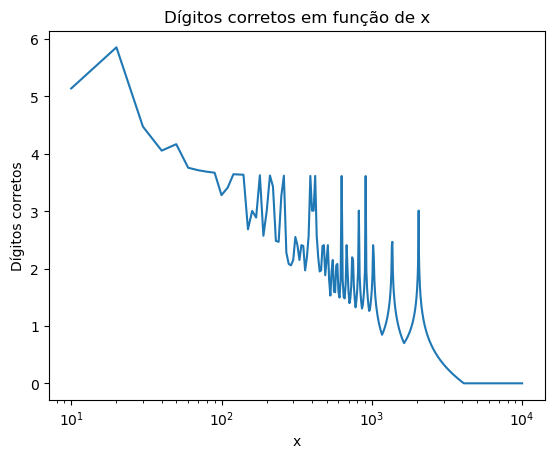

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Expressão que se deseja estudar
def expr(x):
    return np.sqrt(x**2 + 1) - x

# Intervalo de teste [a, b]
a, b = 1.0e1, 1.0e4

################### Possivelmente você não quer editar a partir daqui.

# Erro relativo
def erro_rel(x, xh):
    return np.abs(x - xh) / np.abs(xh)

# Valores de x
x = np.linspace(a, b, 1000)

# Avaliação em precisão dupla (float64)
expr_dupla = expr(x)

# Avaliação em precisão simples (float32)
x_simples = x.astype(np.float32)
expr_simples = expr(x_simples)

# Número de dígitos corretos
log_errorel = np.log10(erro_rel(expr_simples, expr_dupla))

# Gráfico
plt.figure()
plt.plot(x, -log_errorel)
plt.xscale("log")
plt.title("Dígitos corretos em função de x")
plt.xlabel("x")
plt.ylabel("Dígitos corretos")
plt.show()

Como podemos observar no gráfico, a precisão inicialmente é razoável, com mais de **5 dígitos significativos corretos**. No entanto, à medida que $x$ cresce, o número de dígitos corretos diminui rapidamente, chegando a **zero antes de $x = 10^4$**. Isso ocorre devido ao **erro de cancelamento**.

Podemos então perguntar: seria possível evitar esse problema?  
A resposta é **sim**, reescrevendo a expressão de forma equivalente.

Multiplicando pelo conjugado, temos

$$
(\sqrt{x^2 + 1} - x)(\sqrt{x^2 + 1} + x) = x^2 + 1 - x^2 = 1.
$$

Portanto,

$$
\sqrt{x^2 + 1} - x =
\frac{1}{\sqrt{x^2 + 1} + x}.
$$

Essa nova forma **evita o erro de cancelamento**, pois não envolve a subtração de números muito próximos quando $x$ é grande.

Vamos agora calcular os valores usando essa expressão alternativa e comparar os resultados.

C:\Users\jonas\AppData\Local\Temp\ipykernel_27244\4124786168.py:11: RuntimeWarning: divide by zero encountered in log10
  log_errorel = np.log10(erro_rel(expr_simples_alt, expr_dupla))


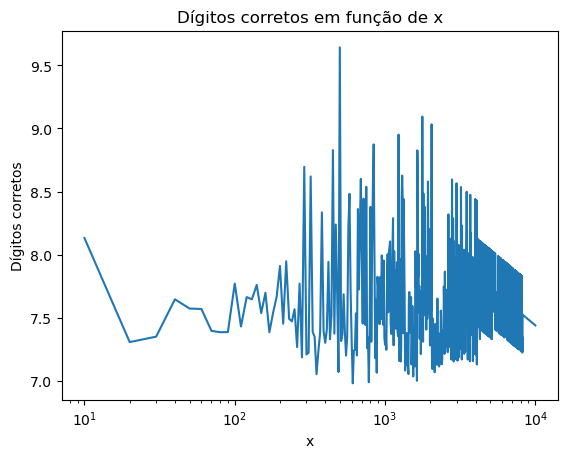

In [24]:
# Versão alternativa que evita erros de cancelamento
def expr_alt(x):
    return 1 / (np.sqrt(x**2 + 1) + x)

################### Possivelmente você não quer editar a partir daqui.

# Calcula a expressão pela fórmula alternativa
expr_simples_alt = expr_alt(x_simples)

# Calcula o erro relativo
log_errorel = np.log10(erro_rel(expr_simples_alt, expr_dupla))

# Remove valores -inf (quando o erro é zero)
mask = np.isfinite(log_errorel)
log_errorel = log_errorel[mask]
x_plot = x[mask]

# Gráfico
plt.figure()
plt.plot(x_plot, -log_errorel)
plt.xscale("log")
plt.title("Dígitos corretos em função de x")
plt.xlabel("x")
plt.ylabel("Dígitos corretos")
plt.show()

C:\Users\jonas\AppData\Local\Temp\ipykernel_27244\2615563912.py:31: RuntimeWarning: divide by zero encountered in log10
  digitos_estavel = -np.log10(erro_rel(expr_simples_alt, expr_dupla))


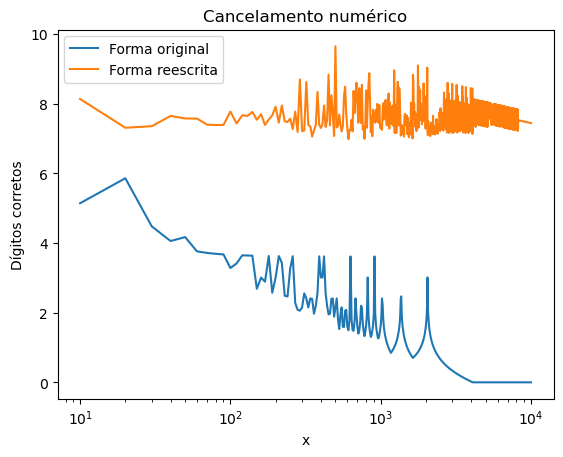

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Expressão original (instável)
def expr(x):
    return np.sqrt(x**2 + 1) - x

# Expressão alternativa (estável)
def expr_alt(x):
    return 1 / (np.sqrt(x**2 + 1) + x)

# Erro relativo
def erro_rel(x, xh):
    return np.abs(x - xh) / np.abs(xh)

# Intervalo
a, b = 1e1, 1e4
x = np.linspace(a, b, 1000)

# Referência em precisão dupla
expr_dupla = expr(x)

# Cálculo em precisão simples
x_simples = x.astype(np.float32)

expr_simples = expr(x_simples)
expr_simples_alt = expr_alt(x_simples)

# Dígitos corretos
digitos_instavel = -np.log10(erro_rel(expr_simples, expr_dupla))
digitos_estavel = -np.log10(erro_rel(expr_simples_alt, expr_dupla))

# Remove valores infinitos
mask1 = np.isfinite(digitos_instavel)
mask2 = np.isfinite(digitos_estavel)

# Gráfico
plt.figure()

plt.plot(x[mask1], digitos_instavel[mask1], label="Forma original")
plt.plot(x[mask2], digitos_estavel[mask2], label="Forma reescrita")

plt.xscale("log")
plt.xlabel("x")
plt.ylabel("Dígitos corretos")
plt.title("Cancelamento numérico")
plt.legend()

plt.show()

Veja como o erro relativo se mantém na ordem do epsilon da máquina para a precisão simples, ou seja $10^{-8}$.

Os exemplos abaixo também apresentam erros de cancelamento para alguns valores de $x$. Identifique esses  valores e apresente uma fórmula alternativa que evita o problema. Pode ser interessante aproveitar o código acima e estudar o erro para *ver* se a sua solução está correta.

1. $\sqrt{1 + x}  - 1$.

1. $\log x - \log y$.

1. $(1 - \cos x)/\sin x$.



In [26]:
# Teste aqui seu código



---

# Misturando números de ordem diferente

Outra situação em que ocorre a perda de dígitos significativos em operações de soma/subtração é quando combinamos números com ordens de grandeza diferentes. Um caso radical disso é quando tentamos somar a um número outro valor de módulo menor que o épsilon da máquina vezes o módulo do número. Nesse caso, não importa o quão complicado seja o  número menor, já sabemos que o resultado vai simplesmente repetir o valor de maior módulo. Isso vem diretamente da forma de representação de números de ponto flutuante e da definição do épsilon da máquina. Veja:

In [27]:
import numpy as np

# Valor do epsilon da máquina para float64
eps_pi = np.finfo(np.float64).eps

# Aproximação de pi em float64
pi64 = np.float64(np.pi)

# Teste da soma
pi64 + 0.5*eps_pi == pi64

True

In [28]:
print("pi =", pi64)
print("epsilon =", eps_pi)
print("pi + eps/2 =", pi64 + 0.5*eps_pi)
print("igual a pi?", pi64 + 0.5*eps_pi == pi64)

pi = 3.141592653589793
epsilon = 2.220446049250313e-16
pi + eps/2 = 3.141592653589793
igual a pi? True


Se isso ocorrer uma única vez, não há grande problema. A resposta obtida é uma ótima aproximação do valor real. Mas isso pode ser um problema se queremos somar um número grande a vários valores pequenos. Nesse caso, os dígitos menos significativos dos números pequenos vão sendo esquecidos durante a soma com o grande a cada soma. Já se os números pequenos fossem somados juntos, poderia ocorrer de eles todos combinados terem um valor mais representativo com relação ao valor maior.

Para deixar isso mais claro, vamos mostrar um exemplo. Sabemos que a somatória
$$
\sum_{k = 1}^\infty \frac{1}{k^2} = \frac{\pi^2}{6}.
$$
Podemos estar interessados em verificar isso experimentalmente no computador, fazendo uma soma parcial, mas com grande número de termos. Isto é feito na forma mais natural pela rotina abaixo.

In [29]:
# soma crescente usando NumPy (vetorizado)
def soma_crescente(N):
    k = np.arange(1, N+1, dtype=np.float32)
    return np.sum(1/(k*k), dtype=np.float32)

**Obs.:** Na função `soma_crescente` utilizamos números em **precisão simples** (`float32`) para tornar os efeitos de erro numérico mais visíveis.

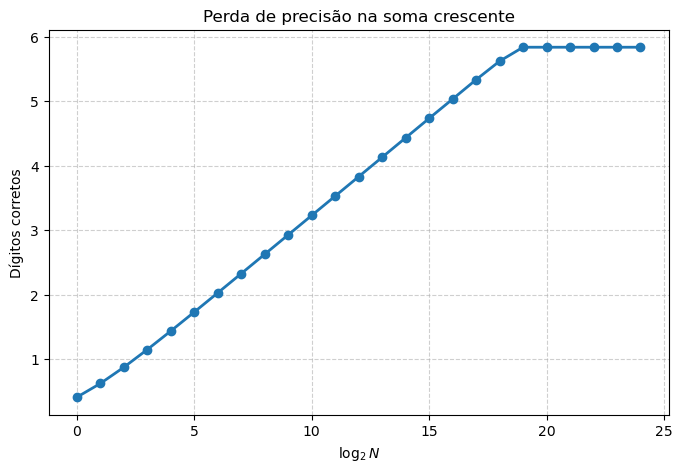

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calcula o erro relativo entre valor aproximado e valor exato
def erro_rel(x_aprox, x_exato):
    return abs(x_aprox - x_exato) / abs(x_exato)

# Calcula a soma da série sum_{k=1}^N 1/k² usando float32
def soma_crescente(N):
    k = np.arange(1, N+1, dtype=np.float32)
    return np.sum(1/(k*k), dtype=np.float32)

# Valor exato da série: π²/6
valor_exato = np.pi**2 / 6

N = 1
Ns = []
erros = []

# Calcula a soma para valores de N que dobram a cada passo
for i in range(25):

    Ns.append(N)

    s = soma_crescente(N)              # soma parcial da série
    erros.append(erro_rel(s, valor_exato))  # erro relativo

    N *= 2                             # dobra N

Ns = np.array(Ns)
erros = np.array(erros)

# Converte erro em número de dígitos corretos
digitos = -np.log10(erros)

# Gráfico: dígitos corretos vs log2(N)
plt.figure(figsize=(8,5))

plt.plot(np.log2(Ns), digitos, marker='o', linewidth=2)

plt.grid(True, linestyle="--", alpha=0.6)

plt.title("Perda de precisão na soma crescente")
plt.xlabel(r"$\log_2 N$")
plt.ylabel("Dígitos corretos")

plt.show()

💡 **Observação:** nas somas acima, quando $k$ é grande, o termo

$$
\frac{1}{k^2}
$$

torna-se muito pequeno em relação à parte inicial da soma, que começa em $1$ e cresce gradualmente. A partir de certo ponto, esses termos passam a ser **pequenos demais para alterar o valor armazenado em ponto flutuante**.

Consequentemente, muitos desses termos deixam de contribuir para a soma. Por isso, ao utilizar números em **precisão simples (`float32`)**, a precisão obtida chega a apenas **4 dígitos corretos**, em vez dos aproximadamente **8 dígitos significativos esperados**.

Uma maneira de reduzir esse problema é realizar a soma **do menor termo para o maior**, em vez de começar pelos maiores termos. Assim, os termos pequenos são primeiro combinados entre si, podendo formar contribuições numericamente mais significativas antes de serem somados ao valor maior.

---

## Soma em ordem decrescente

A seguir definimos uma nova função que realiza a soma **do menor termo para o maior**:

```python
def soma_decrescente(N):
    k = np.arange(N, 0, -1, dtype=np.float32)
    return np.sum(1/(k*k), dtype=np.float32)

Agora calculamos os erros relativos novamente para valores de $N$ iguais a potências de $2$.

In [31]:
def soma_decrescente(N):
    k = np.arange(N, 0, -1, dtype=np.float32)
    return np.sum(1/(k*k), dtype=np.float32)

Cálculo do erro usando soma em ordem decrescente

Agora repetimos o mesmo experimento utilizando a função `soma_decrescente`, que soma os termos da série **do menor para o maior**.


In [32]:
N = 1
erros_dec = []

for i in range(25):
    erros_dec.append(erro_rel(soma_decrescente(N), np.pi*np.pi/6))
    N *= 2

Comparação das duas estratégias

Podemos agora comparar o número de dígitos corretos obtidos ao somar:

- em ordem crescente

- em ordem decrescente

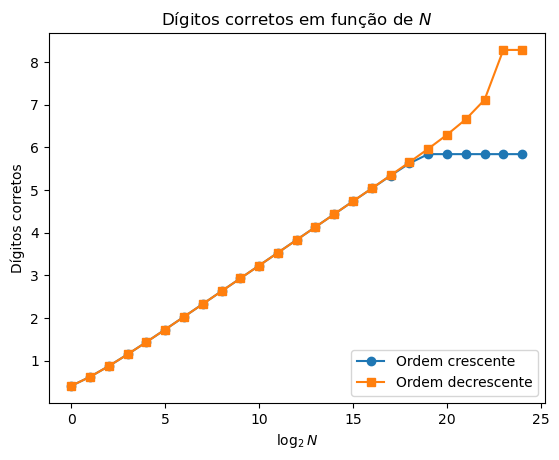

In [33]:
plt.plot(np.log2(Ns), -np.log10(erros), marker='o', label="Ordem crescente")

plt.plot(np.log2(Ns), -np.log10(erros_dec), marker='s',
         label="Ordem decrescente")

plt.legend(loc="lower right")
plt.title("Dígitos corretos em função de $N$")
plt.xlabel(r"$\log_2 N$")
plt.ylabel("Dígitos corretos")

plt.show()

💡 Note que, nessas somas, quando $k$ é grande, o termo

$$
\frac{1}{k^2}
$$

torna-se muito pequeno em relação à parte inicial da soma já calculada, que começa em $1$ e cresce gradualmente. A partir de certo ponto, esses termos tornam-se **pequenos demais para alterar o valor armazenado em ponto flutuante**.

Assim, muitos termos da série deixam de contribuir efetivamente para a soma. Como consequência, ao utilizar números de **precisão simples (`float32`)**, a precisão obtida na soma crescente chega a apenas **cerca de 4 dígitos corretos**, em vez dos aproximadamente **8 dígitos significativos esperados** para esse tipo de representação.

Vamos agora investigar o que acontece se realizarmos a soma **do menor termo para o maior**, isto é, somando primeiro os termos pequenos da série.

Observe que, seguindo a ordem decrescente, a precisão máxima para números de precisão simples, de 8 casas, é atingida.

---

> 📚 **Referência teórica**
>
>> **Material:** *Sistemas de Ponto Flutuante*  
> https://www.ime.unicamp.br/~biloti/an/211/pf-02.html#aprofunde
>
>> Paulo J. S. Silva  
> https://github.com/pjssilva/ms211